# MK Praktikum Unggulan Universitas Gunadarma
# Mata Kuliah: Praktikum Teknologi Kecerdasan Artifisial (Tingkat 1)

---

# Pertemuan Tambahan - Pengganti Minggu ke-7

## Object Detection with Ultralytics YOLO

### Pengenalan
Deteksi objek adalah teknologi yang berada di bawah domain Computer Vision yang lebih luas. Metode ini berkaitan dengan mengidentifikasi dan melacak objek yang ada dalam gambar dan video. Deteksi objek memiliki banyak aplikasi seperti deteksi wajah, deteksi kendaraan, penghitungan pejalan kaki, mobil tanpa pengemudi, sistem keamanan, dll.

Pada materi kali ini, kita akan menggunakan library **Ultralytics** dengan model **YOLOv8 Nano (yolov8n)**. Model ini dirancang untuk sangat akurat, efisien, dan ringan, sehingga sangat optimal dan cepat dijalankan di lingkungan CPU tanpa memerlukan Resource GPU.

### 1. Menyiapkan environment

Proses ini akan memastikan versi kode akan berjalan di model CPU only agar tidak terjadi error memori atau konflik library.

In [1]:
import os
import gc

# Paksa mode CPU only
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
gc.collect()

print("Environment siap.")

Environment siap.


---
### 2. Import Package

Impor library Ultralytics YOLO, Pillow untuk pemrosesan gambar, serta Matplotlib untuk visualisasi hasil.

In [2]:
# Jalankan perintah di bawah ini jika library Ultralytics belum terinstal
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Pastikan library terinstall: !pip install ultralytics
from ultralytics import YOLO
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import gc

### 3. Load Model Pre-trained
Kita akan mengunduh model **yolov8n.pt** langsung dari Ultralytics.

In [4]:
if 'detector' not in globals():
    print("Memuat model ke memori... Mohon tunggu.")
    detector = YOLO("yolov8n.pt")
    print("Model berhasil dimuat.")
else:
    print("Model sudah tersedia di memori.")

Memuat model ke memori... Mohon tunggu.
Model berhasil dimuat.


### 4. Menentukan Gambar Input

Mari tentukan gambar input yang akan dideteksi oleh model.

In [5]:
input_path = "image1.jpg"

### 5. Menjalankan Deteksi Objek

Pada bagian ini, kita membuka gambar, melakukan resize otomatis untuk keamanan memori (RAM), dan mengirimkan data gambar ke model untuk dideteksi.

In [6]:
raw_img = Image.open(input_path)

# Gunakan thumbnail untuk menjaga aspect ratio dan memori
try:
    resampling_filter = Image.Resampling.LANCZOS
except AttributeError:
    resampling_filter = Image.LANCZOS

raw_img.thumbnail((1024, 1024), resampling_filter)
img_array = np.array(raw_img)

# YOLO langsung mendeteksi dari gambar PIL atau Array
results = detector(raw_img)
print(f"Deteksi selesai. Ukuran gambar proses: {img_array.shape}")


0: 384x640 18 cars, 1 truck, 68.2ms
Speed: 27.5ms preprocess, 68.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Deteksi selesai. Ukuran gambar proses: (401, 712, 3)


### 6. Cek Output dan Visualisasi Hasil

Terakhir, kita akan menggambarkan kotak (bounding box) di sekitar objek yang terdeteksi dan menampilkan nama label beserta tingkat probabilitasnya.

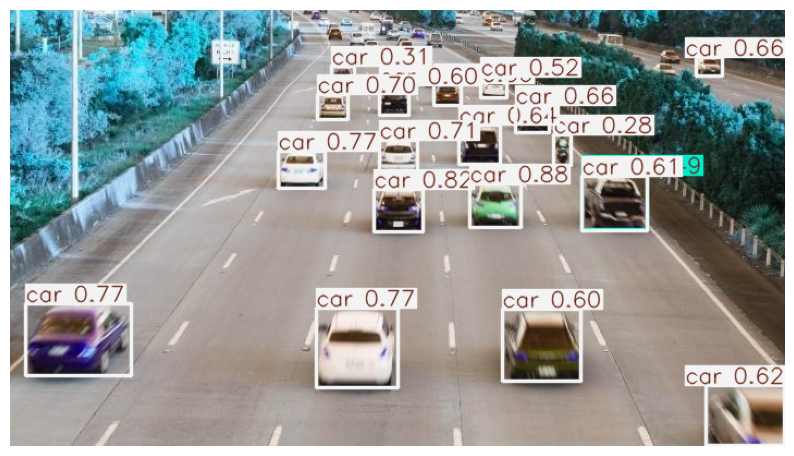

In [7]:
# Ultralytics YOLO memiliki metode plot() bawaan yang membuat visualisasi jauh lebih mudah
res_plotted = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(res_plotted)
plt.axis('off')
plt.show()

### **Tugas Praktikum**

1. Ganti nilai `input_path` dengan `image-2.jpg`.
2. Jalankan cell berurutan dari import library sampai dengan visualisasi.
3. Lihat hasil kotak hijau, label objek, dan nilai confidence.
4. Tulis kesimpulan singkat: objek apa saja terdeteksi, mana yang paling akurat, dan apakah ada kemungkinan error (objek kecil/gelap/tertutup).
5. Konversi file notebook serta penjelasan dan kesimpulannya menjadi file PDF.

# **KESIMPULAN**

Berdasarkan gambar hasil deteksi objek yang Anda unggah, berikut adalah analisis dan kesimpulannya:

3. Hasil Observasi Kotak Deteksi, Label, dan Confidence
- Label: Semua objek yang berhasil diidentifikasi diberi label "car" (mobil).
- Nilai Confidence: Nilai tingkat kepercayaan model (confidence score) bervariasi secara signifikan. Rentang nilainya mulai dari yang paling rendah 0.28 hingga yang paling tinggi 0.88.
- Kotak Pembatas (Bounding Box): Sebagian besar kotak berwarna putih, namun terdapat satu kotak berwarna cyan (hijau kebiruan) pada mobil bak terbuka (pick-up) hitam di lajur kanan, yang anehnya juga menampilkan teks tambahan "-9" di sebelah label confidence "0.61".

4. Kesimpulan Singkat
Objek yang Terdeteksi: Model difokuskan dan berhasil mendeteksi mobil (car) dari berbagai jenis dan warna yang sedang melaju di jalan raya/tol.
- Pendeteksian Paling Akurat: Pendeteksian terbaik jatuh pada mobil berwarna hijau di bagian tengah dengan nilai confidence tertinggi yaitu 0.88, diikuti oleh mobil gelap tepat di sebelah kirinya (0.82). Hal ini karena posisi kedua mobil tersebut berada di tengah dengan pencahayaan yang baik, tidak tertutup objek lain, dan ukurannya relatif jelas (tidak terlalu jauh).
- Kemungkinan Error / Kekurangan:
Objek Kecil/Jauh: Mobil-mobil yang berada jauh di latar belakang memiliki confidence yang sangat rendah (seperti 0.28, 0.31) atau bahkan luput dari deteksi sama sekali (tidak ada kotak pembatas).
- Objek Terpotong (Truncated): Mobil yang berada di pojok kanan bawah terpotong oleh batas frame gambar, sehingga model kurang yakin dan hanya memberikan confidence sebesar 0.62.
- Anomali Output Label: Adanya teks "-9" yang tergabung pada kotak cyan "car 0.61" mengindikasikan adanya glitch, noise, atau error format saat melakukan render label di atas gambar (kemungkinan nilai indeks yang ikut ter-print).
- Kondisi Pencahayaan (Bayangan/Gelap): Area lajur paling kanan yang lebih redup karena bayangan pohon mungkin memengaruhi kualitas ekstraksi fitur, seperti pada deteksi mobil gelap (confidence 0.61) atau mobil abu-abu (confidence 0.66).

<div class="alert alert-warning">
<strong>Perhatian!</strong> Berikut merupakan cara konversi File IPYNB menjadi File PDF untuk melakukan pengumpulan tugas di Virtual Class.
    <a href="https://youtu.be/qXELXtnAK7c">Video konversi</a>.
    </div>

---


Copyright © Pengelola MK Praktikum Unggulan (Praktikum DGX), Universitas Gunadarma


https://www.praktikum-hpc.gunadarma.ac.id/